In [1]:
import pandas as pd
import numpy as np
import gzip

mapping_anno = {
    #------Pro-------
    'NPC_proliferative': 'NPC',
    'NPC': 'NPC',
    'IPC': 'IPC',

    #------EN-------
    'ExN_naive': 'ExN',
    'ExN_immature_1': 'ExN',
    'ExN_immature_2': 'ExN',
    'ExN_immature_3': 'ExN',
    'ExN_mature_1': 'ExN',
    'ExN_mature_2': 'ExN',
    'ExN_mature_3': 'ExN',
    'ExN_ventral': 'ExN',

    #------IN-------
    'InN_naive': 'InN',
    'InN_immature_1': 'InN',
    'InN_immature_2': 'InN',
    'InN_immature_3': 'InN',
    'InN_mature_1': 'InN',
    'InN_mature_2': 'InN',
    'InN_ventral_1': 'InN',
    'InN_ventral_2': 'InN',
    'InN_ventral_3': 'InN',

    #------MN-------
    'MN1': 'MN',
    'MN2': 'MN',

    #------Oligo-------
    'APC_cycling': 'AST',
    'APC_dorsal': 'AST',
    'APC_ventral': 'AST',
    'AST': 'AST',
    'OPC': 'Oligo',
    'COP': 'Oligo',
    'MFOL': 'Oligo',
    'MOL': 'Oligo',

    #------Supp-------
    'RP': 'Ependymal',
    'MP': 'Ependymal',
    'FP': 'Ependymal',

    'EC': 'EC',
    'VLMC': 'VLMC',    
    'PC': 'PC',
    'Microglia': 'Microglia'
}

In [2]:
# Read compressed CSV file
with gzip.open('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/gsMap/Human_Spine/GW17/cauchy_combination/GW17_Neuroticism.Cauchy.csv.gz', 'rt') as f:
    Cauchy = pd.read_csv(f)
Cauchy['Cauchy'] = -np.log10(Cauchy['p_cauchy'])
annotation = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/gsMap/Human_Spine/GW17/report/Neuroticism/gsMap_plot/GW17_Neuroticism_gsMap_plot.csv", index_col=0)
annotation

,sx,sy,p,logp,annotation
GW17:12480_19290,12480.0,19290.0,0.029653,1.527929,Dorsal_Horn
GW17:12540_18780,12540.0,18780.0,0.000030,4.521204,Dorsal_Horn
GW17:15300_19440,15300.0,19440.0,0.338816,0.470036,White_Matter
GW17:12120_19650,12120.0,19650.0,0.002193,2.659005,Dorsal_Horn
GW17:15480_18840,15480.0,18840.0,0.103023,0.987065,Early_White_Matter
...,...,...,...,...,...
GW17:14550_23100,14550.0,23100.0,0.413778,0.383233,Cavity
GW17:14580_23100,14580.0,23100.0,0.521094,0.283084,Cavity
GW17:13980_23010,13980.0,23010.0,0.106426,0.972951,Cavity
GW17:15240_17130,15240.0,17130.0,0.042913,1.367411,Cavity


In [3]:
anno = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW17/spatial_anno.csv", index_col=0)
anno

,cell,celltype
GW17:12480_19290,GW17:12480_19290,ExN_mature_1
GW17:12120_19650,GW17:12120_19650,ExN_immature_1
GW17:14520_19170,GW17:14520_19170,APC_cycling
GW17:14370_18450,GW17:14370_18450,APC_dorsal
GW17:16320_20970,GW17:16320_20970,MFOL
...,...,...
GW17:11820_20490,GW17:11820_20490,VLMC
GW17:15780_21750,GW17:15780_21750,APC_dorsal
GW17:16710_20580,GW17:16710_20580,ExN_immature_2
GW17:12420_17340,GW17:12420_17340,EC


In [4]:
anno['annotation'] = anno.index.map(annotation['annotation'])
anno['celltype'] = anno['celltype'].map(mapping_anno)

In [5]:
anno

,cell,celltype,annotation
GW17:12480_19290,GW17:12480_19290,ExN,Dorsal_Horn
GW17:12120_19650,GW17:12120_19650,ExN,Dorsal_Horn
GW17:14520_19170,GW17:14520_19170,AST,MN_Horn
GW17:14370_18450,GW17:14370_18450,AST,MN_Horn
GW17:16320_20970,GW17:16320_20970,Oligo,MN_Horn
...,...,...,...
GW17:11820_20490,GW17:11820_20490,VLMC,Meninge
GW17:15780_21750,GW17:15780_21750,AST,MN_Horn
GW17:16710_20580,GW17:16710_20580,ExN,Meninge
GW17:12420_17340,GW17:12420_17340,EC,Meninge


In [6]:
# 1. Compute cell-type proportion for each annotation
celltype_prop = (anno.groupby(['annotation', 'celltype'])
                .size()
                .unstack(fill_value=0)
                .apply(lambda x: x/x.sum()*100, axis=1)
                .round(2))

# 2. Merge results into Cauchy matrix
Cauchy_merged = Cauchy.merge(
    celltype_prop, 
    left_on='annotation', 
    right_index=True, 
    how='left'
).fillna(0)  # Replace NaN with 0
Cauchy_merged

,annotation,p_cauchy,p_median,Cauchy,AST,EC,Ependymal,ExN,IPC,InN,MN,Microglia,NPC,Oligo,PC,VLMC
0,Dorsal_Horn,0.000012,0.003018,4.928292,4.13,1.85,0.00,56.32,1.33,29.03,1.39,0.43,0.78,4.74,0.00,0.00
1,Intermediate_Gray,0.000092,0.004385,4.036924,13.90,2.24,0.07,29.37,4.62,35.91,4.26,0.79,2.50,6.35,0.00,0.00
2,Ventral_Horn,0.000722,0.002903,3.141549,9.60,0.00,0.00,28.00,4.00,28.80,8.80,0.00,0.80,20.00,0.00,0.00
3,MN_Horn,0.001653,0.044080,2.781830,20.87,2.84,0.03,21.04,5.82,23.06,11.83,1.16,2.68,10.64,0.00,0.02
4,Early_White_Matter,0.011094,0.059738,1.954898,32.21,3.37,0.00,15.58,5.68,11.79,3.58,1.26,4.84,21.68,0.00,0.00
5,White_Matter,0.013523,0.104507,1.868924,17.10,2.97,0.09,6.22,2.29,5.67,1.67,3.23,4.45,56.17,0.04,0.09
6,VZ,0.014024,0.122084,1.853123,41.15,4.47,7.08,4.77,2.36,4.87,0.54,1.87,5.36,27.48,0.00,0.05
7,Early_Horn/Lateral_Horn,0.025154,0.039522,1.599392,7.89,0.00,0.00,31.58,0.00,39.47,5.26,0.00,2.63,13.16,0.00,0.00
8,Cavity,0.025777,0.158576,1.588765,21.71,1.01,0.00,18.95,5.05,18.51,2.59,3.08,2.99,25.71,0.04,0.35
9,Meninge,0.131625,0.365202,0.880662,20.56,24.77,0.03,5.74,3.08,6.35,1.01,3.05,2.87,9.16,4.28,19.09


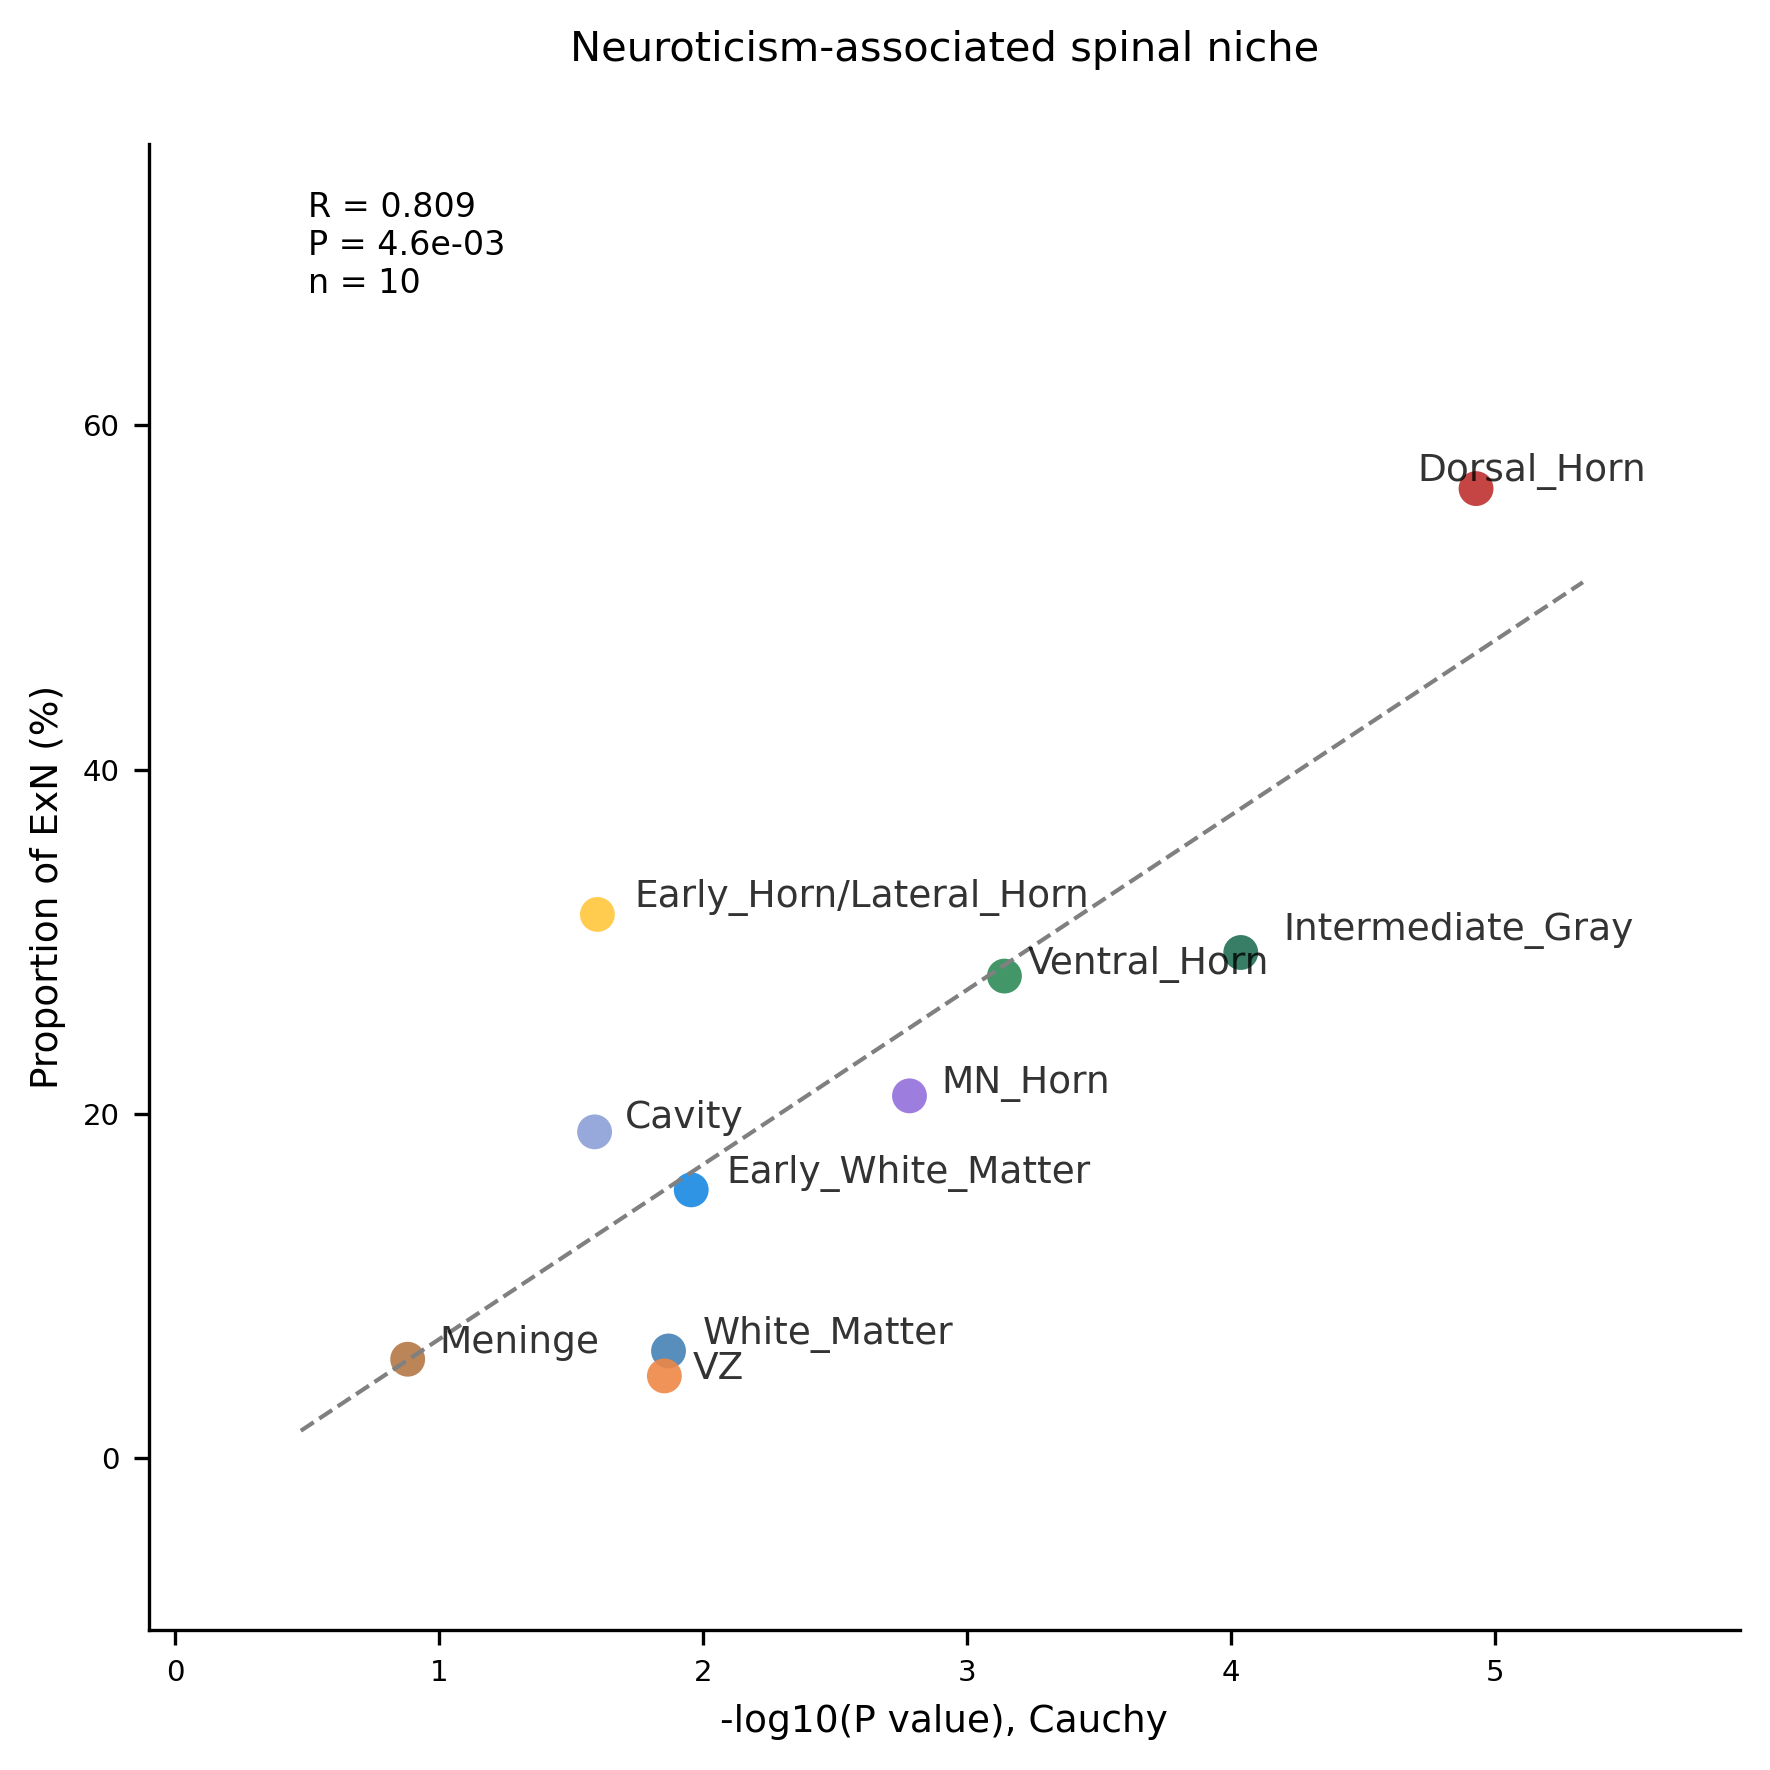

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from adjustText import adjust_text


plt.rcParams['pdf.fonttype'] = 42  # Best compatibility mode
plt.rcParams['ps.fonttype'] = 42


# 1. Prepare data
celltype = 'ExN'
x = Cauchy_merged['Cauchy']
y = Cauchy_merged[celltype]
annotations = Cauchy_merged['annotation']

# 2. Compute correlation
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
n = len(Cauchy_merged)

latent_niche_colors = {
    'Dorsal_Horn': "#BF3131",  
    'Cavity': "#8ca0d7",     
    'MN_Horn': '#9370DB', 
    'Meninge': "#b47846",    
    'White_Matter': '#4682B4',    
    'Intermediate_Gray': "#226f54",      
    'VZ': '#EF8746',      
    'Ventral_Horn': "#2E8B57",   
    'Early_Horn/Lateral_Horn': "#FFC73D",
    'Early_White_Matter': "#1988E3B7",
    '-1': '#DCDCDC'          
}

# 3. Create figure
plt.figure(figsize=(6, 6), dpi=300)

# Use the provided color scheme
colors = [latent_niche_colors[ann] for ann in annotations]

# Draw scatter plot (no black edge)
scatter = plt.scatter(
    x=x, 
    y=y,
    c=colors,
    s=70,           # Point size
    alpha=0.9,       # Transparency
    linewidths=0     # Remove black edge
)

# Compute extended x range for regression line
x_min, x_max = min(x), max(x)
x_extend = 0.1 * (x_max - x_min)
x_line = np.linspace(x_min - x_extend, x_max + x_extend, 100)  # Generate 100 points

# Compute corresponding y values
y_line = intercept + slope * x_line 

# Add regression line
plt.plot(
    x_line, 
    y_line, 
    color='grey', 
    linestyle='--',
    linewidth=1
)

# 4. Smart text labeling (avoid text overlap only)
texts = []
for i, txt in enumerate(annotations):
    texts.append(plt.text(
        x[i] + 0.1,  # Initial horizontal offset
        y[i],    # Initial vertical offset
        txt,
        fontsize=9,
        alpha=0.8
    ))

# Auto-adjust text positions (avoid text overlap only)
adjust_text(texts,
            arrowprops=None,  # Disable leader lines
            avoid_points=False,  # Allow text-point overlap
            avoid_text=True,    # Force non-overlap among texts
            expand_text=(1.2, 1.2),  # Minimum text spacing
            force_text=(0.8, 0.5),   # Repulsion strength
            lim=100)

# 5. Add statistics
stats_text = f'R = {r_value:.3f}\nP = {p_value:.1e}\nn = {n}'
plt.text(
    0.1, 0.9, 
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=8
)

# 6. Axis labels
plt.xlabel('-log10(P value), Cauchy', fontsize=9)
plt.ylabel(f'Proportion of {celltype} (%)', fontsize=9)
plt.title('Neuroticism-associated spinal niche', fontsize=10, pad=20)

# Adjust x-axis ticks
plt.xticks(np.arange(0, max(x)+0.5, 1), fontsize=7)  # Start at 0 with step 1
plt.xlim(-0.1, max(x)+1)  # Set x-axis range

# Adjust y-axis ticks
plt.yticks(np.arange(0, max(y)+20, 20), fontsize=7)  # Start at 0 with step 20
plt.ylim(-10, max(y)+20)  # Set y-axis range

sns.despine()

plt.tight_layout()

# Save as editable PDF
plt.savefig('./figure/neuroticism_spinal_niche.pdf', 
           format='pdf', 
           bbox_inches='tight',
           dpi=300,
           transparent=True)  # Keep transparent background

# plt.show()

In [10]:
import pandas as pd
from scipy import stats

# Prepare a list to store results
results_list = []

# Get all cell-type columns (excluding non-cell-type columns)
celltypes = [col for col in Cauchy_merged.columns if col not in ['annotation', 'p_cauchy', 'p_median', 'Cauchy']]

# Perform linear regression for each cell type
for celltype in celltypes:
    x = Cauchy_merged['Cauchy']
    y = Cauchy_merged[celltype]
    
    # Run linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Append result to list
    results_list.append({
        'celltype': celltype,
        'r_value': r_value,
        'p_value': p_value,
        'slope': slope,
        'intercept': intercept
    })

# Convert list to DataFrame
results = pd.DataFrame(results_list)

# Sort by p value
results = results.sort_values('p_value')

# Display results
results

,celltype,r_value,p_value,slope,intercept
3,ExN,0.809028,0.004589,10.148950,-3.244288
8,NPC,-0.608387,0.061991,-0.747939,4.832499
7,Microglia,-0.600902,0.066172,-0.605890,2.979571
5,InN,0.567240,0.087242,5.827380,5.990622
0,AST,-0.510686,0.131462,-4.591401,30.222621
1,EC,-0.452398,0.189259,-2.643309,10.863622
11,VLMC,-0.451000,0.190802,-2.167997,7.300721
10,PC,-0.448844,0.193195,-0.484135,1.628635
9,Oligo,-0.415095,0.232924,-5.024968,31.887685
6,MN,0.200925,0.577794,0.588877,2.642339


In [11]:
import os
import gzip
import pandas as pd
from scipy import stats

# Define path and file pattern
input_dir = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/gsMap/Human_Spine/GW17/cauchy_combination/"

# Define other required file paths
annotation_path = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/gsMap/Human_Spine/GW17/report/PTSD/gsMap_plot/GW17_PTSD_gsMap_plot.csv"
anno_path = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW17/spatial_anno.csv"

# Load annotation data
annotation = pd.read_csv(annotation_path, index_col=0)
anno = pd.read_csv(anno_path, index_col=0)
anno['annotation'] = anno.index.map(annotation['annotation'])
anno['celltype'] = anno['celltype'].map(mapping_anno)

# Compute cell-type proportions
celltype_prop = (anno.groupby(['annotation', 'celltype'])
                .size()
                .unstack(fill_value=0)
                .apply(lambda x: x/x.sum()*100, axis=1)
                .round(2))

# Get all trait files
trait_files = [f for f in os.listdir(input_dir) if f.endswith('.Cauchy.csv.gz')]
trait_names = [f.split('.')[0] for f in trait_files]  # Extract trait names

# Initialize result matrix
celltypes = celltype_prop.columns.tolist()
r_matrix = pd.DataFrame(index=celltypes, columns=trait_names)
p_matrix = pd.DataFrame(index=celltypes, columns=trait_names)

# Process each trait file
for trait_file, trait_name in zip(trait_files, trait_names):
    # Read Cauchy file
    with gzip.open(os.path.join(input_dir, trait_file), 'rt') as f:
        cauchy = pd.read_csv(f)
    
    # Compute -log10(p_cauchy)
    cauchy['Cauchy'] = -np.log10(cauchy['p_cauchy'])
    
    # Merge cell-type proportions
    cauchy_merged = cauchy.merge(
        celltype_prop, 
        left_on='annotation', 
        right_index=True, 
        how='left'
    ).fillna(0)
    
    # Compute correlation for each cell type
    for celltype in celltypes:
        x = cauchy_merged['Cauchy']
        y = cauchy_merged[celltype]
        
        # Run linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        
        # Store result
        r_matrix.loc[celltype, trait_name] = r_value
        p_matrix.loc[celltype, trait_name] = p_value

r_matrix

,GW17_ALS,GW17_MS,GW17_BP,GW17_Neuroticism,GW17_Height,GW17_IQ,GW17_SPA,GW17_SCZ,GW17_AD,GW17_AN,...,GW17_AHD,GW17_AR,GW17_ATM,GW17_Benign,GW17_CRPS,GW17_Encephalitis,GW17_GGE,GW17_Insomnia,GW17_Parasomnia,GW17_AD2
AST,-0.109952,0.022988,-0.318912,-0.510686,0.692646,-0.444324,0.022825,-0.518384,0.529595,-0.723452,...,0.204595,-0.039774,-0.67087,0.059206,-0.292781,-0.493551,0.637372,0.439894,0.433106,0.53987
EC,0.121688,0.970461,-0.395001,-0.452398,0.66591,-0.561711,-0.288963,-0.498287,0.705168,-0.389065,...,-0.401754,-0.598167,-0.362207,-0.243193,0.676851,-0.154294,0.778985,-0.026062,0.50472,0.287042
Ependymal,0.0491,-0.134068,-0.060414,-0.171072,0.458556,-0.026896,-0.038419,0.001015,0.404712,-0.27247,...,0.391376,0.179591,-0.413185,-0.162937,-0.209186,-0.37663,0.45531,0.119036,0.19148,0.23174
ExN,-0.050137,-0.34541,0.606671,0.809028,-0.874046,0.747672,0.242777,0.787367,-0.663779,0.683885,...,-0.096669,0.606978,0.906106,-0.058479,0.21008,0.244004,-0.720421,-0.452046,-0.557295,-0.596113
IPC,-0.245864,-0.103343,-0.196785,0.00599,0.057538,-0.075853,-0.056051,-0.265286,0.065079,-0.569236,...,0.021557,0.274796,-0.039717,0.514182,-0.074947,-0.314434,0.017756,0.424606,-0.032977,0.351742
InN,-0.30791,-0.344688,0.493474,0.56724,-0.907594,0.597452,0.274171,0.587324,-0.643076,0.79725,...,0.304883,0.493199,0.620638,0.195062,0.001431,0.040896,-0.761599,-0.654935,-0.858457,-0.600891
MN,-0.257646,-0.279507,-0.032091,0.200925,-0.474487,0.219459,0.039838,0.069172,-0.364093,0.269803,...,0.402485,0.350477,0.370909,0.88652,-0.106158,-0.106242,-0.54427,-0.224705,-0.47368,0.034884
Microglia,0.143988,0.402337,-0.408522,-0.600902,0.81538,-0.662152,-0.610599,-0.604176,0.591229,-0.794984,...,-0.451668,-0.628435,-0.68883,-0.263622,-0.118348,0.022732,0.707693,0.773726,0.713612,0.422269
NPC,0.103239,-0.029192,-0.157555,-0.608387,0.728367,-0.493284,0.030165,-0.529471,0.550953,-0.641948,...,0.2608,-0.337713,-0.804097,-0.026722,-0.513862,-0.12981,0.633884,0.4071,0.579724,0.61196
Oligo,0.386146,-0.249321,-0.310954,-0.415095,0.470935,-0.335703,-0.178188,-0.325212,0.134978,-0.3596,...,-0.036981,-0.488179,-0.52931,-0.131106,-0.549362,0.370172,0.161103,0.630686,0.529744,0.342703


In [12]:
p_matrix

,GW17_ALS,GW17_MS,GW17_BP,GW17_Neuroticism,GW17_Height,GW17_IQ,GW17_SPA,GW17_SCZ,GW17_AD,GW17_AN,...,GW17_AHD,GW17_AR,GW17_ATM,GW17_Benign,GW17_CRPS,GW17_Encephalitis,GW17_GGE,GW17_Insomnia,GW17_Parasomnia,GW17_AD2
AST,0.762367,0.949741,0.369106,0.131462,0.026406,0.198268,0.950097,0.124768,0.115406,0.018037,...,0.570716,0.913133,0.033712,0.87094,0.411675,0.147142,0.047449,0.203314,0.211189,0.107223
EC,0.737715,0.000003,0.258599,0.189259,0.03555,0.091069,0.418082,0.1427,0.022738,0.266471,...,0.249803,0.067744,0.303693,0.498377,0.031584,0.670402,0.007917,0.943029,0.136798,0.421323
Ependymal,0.892852,0.711941,0.868326,0.63654,0.182554,0.941208,0.916081,0.99778,0.246004,0.446285,...,0.263391,0.619572,0.2353,0.652889,0.561909,0.283379,0.186071,0.743267,0.59616,0.519427
ExN,0.8906,0.328293,0.062934,0.004589,0.000943,0.012909,0.499136,0.006857,0.03636,0.029199,...,0.790502,0.062765,0.000303,0.872513,0.560201,0.496901,0.018765,0.189647,0.0942,0.068942
IPC,0.493522,0.776337,0.585819,0.986898,0.874551,0.835023,0.877774,0.458832,0.858241,0.085887,...,0.952866,0.442256,0.913256,0.128395,0.836972,0.376241,0.961171,0.221295,0.927941,0.318902
InN,0.386755,0.329373,0.147215,0.087242,0.000285,0.068159,0.443337,0.074218,0.044884,0.005742,...,0.391682,0.147475,0.05553,0.589169,0.996869,0.910689,0.010477,0.039854,0.001475,0.066179
MN,0.472345,0.434148,0.929873,0.577794,0.165866,0.542394,0.912992,0.849408,0.300994,0.450924,...,0.248861,0.320766,0.291347,0.000631,0.770379,0.770202,0.103833,0.532534,0.166688,0.923785
Microglia,0.691476,0.249053,0.241158,0.066172,0.004041,0.036986,0.06079,0.064321,0.071842,0.005985,...,0.190064,0.051659,0.027599,0.46176,0.74471,0.950299,0.022044,0.008639,0.020474,0.224121
NPC,0.776556,0.936197,0.663778,0.061991,0.016899,0.147395,0.934073,0.115507,0.098816,0.045384,...,0.466745,0.339898,0.005049,0.941588,0.128674,0.720777,0.049064,0.24296,0.078987,0.060059
Oligo,0.270389,0.487267,0.381832,0.232924,0.169504,0.342962,0.622355,0.359184,0.710057,0.307446,...,0.919215,0.152281,0.115638,0.718085,0.099996,0.292382,0.656592,0.050576,0.115284,0.33235


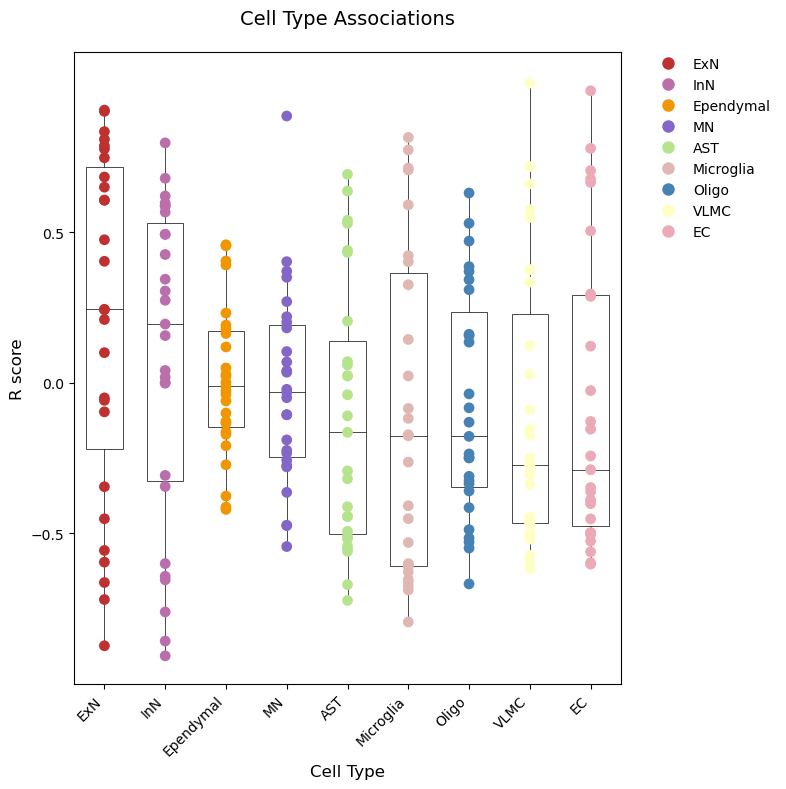

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Color definitions
major_colors = {
    'ExN': '#BF3131',
    'InN': '#ba6eac',
    'MN': '#8367c7',
    'AST': '#b5e48c',
    'Oligo': '#4682B4',
    'Ependymal': '#F09600',
    'Microglia': '#DFB8B3',
    'EC': '#eca9b8',
    'VLMC': '#FEFFC4'
}

# Prepare data - filter and reshape
filtered_r_matrix = r_matrix.loc[list(major_colors.keys())]  # Keep only cell types with predefined colors
r_df = filtered_r_matrix.reset_index().melt(id_vars='index', var_name='Trait', value_name='R_value')
r_df = r_df.rename(columns={'index': 'Celltype'})

# Sort cell types by median
celltype_order = r_df.groupby('Celltype')['R_value'].median().sort_values(ascending=False).index.tolist()

# Create plot
plt.figure(figsize=(8, 8))  # Use a more balanced figure size

# First draw scatter points (ensure top layer)
for celltype in celltype_order:
    celltype_data = r_df[r_df['Celltype'] == celltype]
    plt.scatter(
        [celltype_order.index(celltype)] * len(celltype_data),
        celltype_data['R_value'],
        color=major_colors[celltype],
        alpha=1,  # Higher opacity for visibility
        s=60,      # Slightly larger points
        edgecolor='none',
        linewidth=0,
        label=celltype,
        zorder=3  # Keep scatter points on top
    )

# Then draw boxplots (below scatter points)
sns.boxplot(
    x='Celltype',
    y='R_value',
    data=r_df,
    order=celltype_order,
    color='white',
    width=0.6,
    showfliers=False,
    boxprops={'facecolor':'none', 'edgecolor':'black', 'linewidth':0.5, 'zorder':2},
    whiskerprops={'color':'black', 'linewidth':0.5, 'zorder':2},
    capprops={'color':'black', 'visible': False, 'zorder':2},
    medianprops={'color':'black', 'linewidth':0.5, 'zorder':2}
)

# Customize plot elements
plt.title('Cell Type Associations', fontsize=14, pad=20)
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('R score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(np.arange(-0.5, 0.6, 0.5))
plt.ylim(-1, 1.1)

# Add legend (cell types only)
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=major_colors[ct], 
                     markersize=10, label=ct) for ct in celltype_order]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), 
           loc='upper left', borderaxespad=0, frameon=False)

plt.tight_layout()
plt.show()

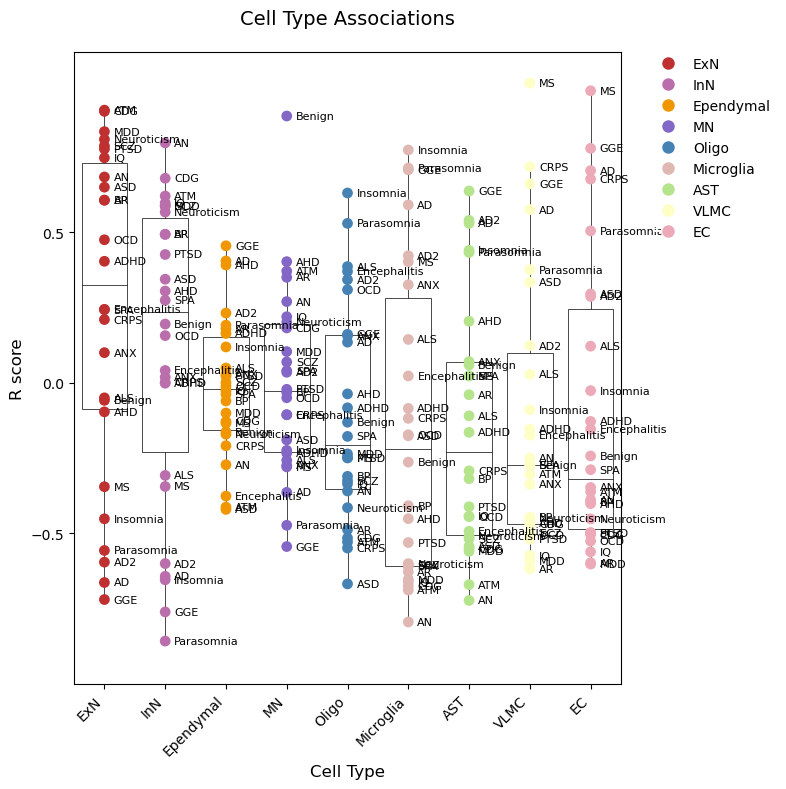

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Color definitions
major_colors = {
    'ExN': '#BF3131',
    'InN': '#ba6eac',
    'MN': '#8367c7',
    'AST': '#b5e48c',
    'Oligo': '#4682B4',
    'Ependymal': '#F09600',
    'Microglia': '#DFB8B3',
    'EC': '#eca9b8',
    'VLMC': '#FEFFC4'
}

# Prepare data - filter and reshape
filtered_r_matrix = r_matrix.drop('GW17_Height', axis=1).loc[list(major_colors.keys())]  # Keep only cell types with predefined colors
r_df = filtered_r_matrix.reset_index().melt(id_vars='index', var_name='Trait', value_name='R_value')
r_df = r_df.rename(columns={'index': 'Celltype'})

# Sort cell types by median
celltype_order = r_df.groupby('Celltype')['R_value'].median().sort_values(ascending=False).index.tolist()

# Create plot
plt.figure(figsize=(8, 8))

# First draw scatter points (ensure top layer)
for celltype in celltype_order:
    celltype_data = r_df[r_df['Celltype'] == celltype]
    sc = plt.scatter(
        [celltype_order.index(celltype)] * len(celltype_data),
        celltype_data['R_value'],
        color=major_colors[celltype],
        alpha=1,
        s=60,
        edgecolor='none',
        linewidth=0,
        label=celltype,
        zorder=3
    )
    
    # Add trait label for each point
    for i, row in celltype_data.iterrows():
        plt.text(
            celltype_order.index(celltype)+ 0.15,
            row['R_value'],
            row['Trait'].replace('GW17_', ''),
            fontsize=8,
            ha='left',
            va='center',
            zorder=4
        )

# Then draw boxplots (below scatter points)
sns.boxplot(
    x='Celltype',
    y='R_value',
    data=r_df,
    order=celltype_order,
    color='white',
    width=0.75,
    showfliers=False,
    boxprops={'facecolor':'none', 'edgecolor':'black', 'linewidth':0.5, 'zorder':2},
    whiskerprops={'color':'black', 'linewidth':0.5, 'zorder':2},
    capprops={'color':'black', 'visible': False, 'zorder':2},
    medianprops={'color':'black', 'linewidth':0.5, 'zorder':2}
)

# Customize plot elements
plt.title('Cell Type Associations', fontsize=14, pad=20)
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('R score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(np.arange(-0.5, 0.6, 0.5))
plt.ylim(-1, 1.1)

# Add legend (cell types only)
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=major_colors[ct], 
                     markersize=10, label=ct) for ct in celltype_order]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), 
           loc='upper left', borderaxespad=0, frameon=False)
plt.savefig('./figure/cell_type_associations.pdf', 
            format='pdf',
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.1,
            transparent=False)  # Opaque background
plt.tight_layout()
plt.show()